In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import warnings
import torch
import torch.nn as nn
import h5py
import pywt
from scipy.signal import butter, filtfilt, windows
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from captum.attr import InputXGradient, IntegratedGradients, GradientShap, GuidedBackprop


In [ ]:
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.dpi'] = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

path = '/content/drive/Shareddrives/XAI Project Shared Drive'


X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")

Using Device: cuda
Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


# Preprocessing

In [ ]:
def preprocess_ecg(signal_100hz):

    processed_signal = np.zeros_like(signal_100hz)

    nyquist = 0.5 * 100
    normal_cutoff = 0.3 / nyquist
    b, a = butter(4, normal_cutoff, btype='high', analog=False)

    tukey_win = windows.tukey(signal_100hz.shape[0], alpha=0.06)

    for lead in range(signal_100hz.shape[1]):
        lead_sig = signal_100hz[:, lead]

        lead_sig = filtfilt(b, a, lead_sig)

        coeffs = pywt.wavedec(lead_sig, 'sym5', level=8)

        coeffs[1:] = [pywt.threshold(c, value=np.std(c)/2, mode='soft') for c in coeffs[1:]]
        lead_sig = pywt.waverec(coeffs, 'sym5')[:1000]
        lead_sig = lead_sig * tukey_win
        min_val, max_val = np.min(lead_sig), np.max(lead_sig)
        if max_val > min_val:
            lead_sig = (lead_sig - min_val) / (max_val - min_val)

        processed_signal[:, lead] = lead_sig

    return processed_signal

X_processed = np.array([preprocess_ecg(sig) for sig in tqdm(X)])

100%|██████████| 21799/21799 [04:47<00:00, 75.86it/s]


In [ ]:
import os
import numpy as np

save_dir = '/content/drive/MyDrive/XAI_Project'
file_name = 'xECG_preprocessing.npy'
full_path = os.path.join(save_dir, file_name)

os.makedirs(save_dir, exist_ok=True)
print(f"Saving X_processed to {full_path}...")
np.save(full_path, X_processed)
print("Save complete! You can load it later using np.load()")

Saving X_processed to /content/drive/MyDrive/XAI_Project/xECG_preprocessing.npy...
Save complete! You can load it later using np.load()


In [ ]:
# loading it later
X_processed = np.load('/content/drive/MyDrive/XAI_Project/xECG_preprocessing.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')

# DataLoaders

In [ ]:
import ast

agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]


df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

print("\nSample of Superclass Targets:")
display(df_ptbxl[['diagnostic_superclass'] + superclasses].head())


Sample of Superclass Targets:


,diagnostic_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

Y = df_ptbxl[superclasses].values

train_mask = df_ptbxl['strat_fold'] <= 8
val_mask = df_ptbxl['strat_fold'] == 9
test_mask = df_ptbxl['strat_fold'] == 10

X_train, Y_train = X_processed[train_mask], Y[train_mask]
X_val, Y_val     = X_processed[val_mask], Y[val_mask]
X_test, Y_test   = X_processed[test_mask], Y[test_mask]

print("=== Dataset Splits ===")
print(f"Train samples: {X_train.shape[0]}")
print(f"Val samples  : {X_val.shape[0]}")
print(f"Test samples : {X_test.shape[0]}")


class ECGDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        signal = self.x_data[idx]
        label = self.y_data[idx]

        signal = np.transpose(signal, (1, 0))

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return signal_tensor, label_tensor


BATCH_SIZE = 64


train_loader = DataLoader(ECGDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(ECGDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(ECGDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)


sample_batch_x, sample_batch_y = next(iter(train_loader))
print("\n=== DataLoader Sanity Check ===")
print(f"Input Batch Shape  : {sample_batch_x.shape} -> [Batch, Leads, Time]")
print(f"Target Batch Shape : {sample_batch_y.shape} -> [Batch, Classes]")

=== Dataset Splits ===
Train samples: 17418
Val samples  : 2183
Test samples : 2198

=== DataLoader Sanity Check ===
Input Batch Shape  : torch.Size([64, 12, 1000]) -> [Batch, Leads, Time]
Target Batch Shape : torch.Size([64, 5]) -> [Batch, Classes]


# Model

In [ ]:
class xECGArch(nn.Module):
    def __init__(self, num_classes=5, w_st=1.0, w_lt=1.2675):
        super(xECGArch, self).__init__()
        self.w_st = w_st
        self.w_lt = w_lt


        st_filters = [12, 96, 96, 96, 48, 48, 48, 24, 24, 24]
        st_kernels = [16, 17, 17, 30, 30, 30, 56, 56, 56]

        st_layers = []
        for i in range(len(st_kernels)):
            st_layers.append(nn.Conv1d(st_filters[i], st_filters[i+1], kernel_size=st_kernels[i], padding='same'))
            st_layers.append(nn.BatchNorm1d(st_filters[i+1]))
            st_layers.append(nn.ReLU())

        self.st_branch = nn.Sequential(*st_layers)
        self.st_pool = nn.AdaptiveAvgPool1d(1)
        self.st_fc = nn.Linear(24, num_classes)


        lt_filters = [12, 128, 128, 128, 64, 64, 64, 32, 32, 32]
        lt_kernels = [34, 35, 35, 35, 33, 33, 33, 33, 33]
        lt_strides = [1, 1, 1, 8, 1, 1, 8, 1, 1]

        lt_layers = []
        for i in range(len(lt_kernels)):
            padding = lt_kernels[i] // 2
            lt_layers.append(nn.Conv1d(lt_filters[i], lt_filters[i+1], kernel_size=lt_kernels[i], stride=lt_strides[i], padding=padding))
            lt_layers.append(nn.BatchNorm1d(lt_filters[i+1]))
            lt_layers.append(nn.ReLU())

        self.lt_branch = nn.Sequential(*lt_layers)
        self.lt_pool = nn.AdaptiveAvgPool1d(1)
        self.lt_fc = nn.Linear(32, num_classes)


    def forward(self, x):
        x_st = self.st_branch(x)
        x_st = self.st_pool(x_st).squeeze(-1)
        out_st = self.st_fc(x_st)

        x_lt = self.lt_branch(x)
        x_lt = self.lt_pool(x_lt).squeeze(-1)
        out_lt = self.lt_fc(x_lt)

        out_ensemble = ((out_st * self.w_st) + (out_lt * self.w_lt)) / (self.w_st + self.w_lt)

        return out_ensemble

model = xECGArch(num_classes=5).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:

            if torch.isnan(X_batch).any() or torch.isinf(X_batch).any():
                continue

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()


            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    avg_loss = val_loss / len(loader)

    try:
        macro_auc = roc_auc_score(all_targets, all_preds, average='macro')
    except ValueError:
        macro_auc = 0.0

    return avg_loss, macro_auc

epochs = 40
best_auc = 0.0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):

        if torch.isnan(X_batch).any() or torch.isinf(X_batch).any():
            continue

        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()


        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    val_loss, val_auc = evaluate(model, val_loader)
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val Macro AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), f'{path}/xecgarch_best_weights.pth')
        print("--> Saved new best model!")

Epoch 1/40: 100%|██████████| 272/272 [00:59<00:00,  4.58it/s]


Train Loss: 0.4881 | Val Loss: 0.4412 | Val Macro AUC: 0.7909
--> Saved new best model!


Epoch 2/40: 100%|██████████| 272/272 [01:02<00:00,  4.37it/s]


Train Loss: 0.3968 | Val Loss: 0.3814 | Val Macro AUC: 0.8298
--> Saved new best model!


Epoch 3/40: 100%|██████████| 272/272 [01:02<00:00,  4.36it/s]


...

Train Loss: 0.2052 | Val Loss: 0.3663 | Val Macro AUC: 0.8856


Epoch 39/40: 100%|██████████| 272/272 [01:00<00:00,  4.46it/s]


Train Loss: 0.1999 | Val Loss: 0.3625 | Val Macro AUC: 0.8873


Epoch 40/40: 100%|██████████| 272/272 [01:00<00:00,  4.47it/s]


Train Loss: 0.1969 | Val Loss: 0.3641 | Val Macro AUC: 0.8840


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report

print("=== Evaluating Final Model on Test Set ===")

model.load_state_dict(torch.load(f'{path}/xecgarch_best_weights.pth'))
model.eval()

all_preds = []
all_targets = []


with torch.no_grad():
    for X_batch, y_batch in test_loader:

        if torch.isnan(X_batch).any() or torch.isinf(X_batch).any():
            continue

        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        preds = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

try:
    test_macro_auc = roc_auc_score(all_targets, all_preds, average='macro')
except ValueError:
    test_macro_auc = 0.0

print(f"\nFINAL TEST MACRO AUC: {test_macro_auc:.4f}")
print("-" * 40)


print("PER-CLASS AUC SCORES:")
per_class_auc = roc_auc_score(all_targets, all_preds, average=None)
for i, class_name in enumerate(superclasses):
    print(f"  {class_name}: {per_class_auc[i]:.4f}")


preds_discrete = (all_preds > 0.5).astype(int)

print("-" * 40)
print("\nDETAILED CLASSIFICATION REPORT (Threshold = 0.5):")
print(classification_report(all_targets, preds_discrete, target_names=superclasses))

=== Evaluating Final Model on Test Set ===

FINAL TEST MACRO AUC: 0.8885
----------------------------------------
PER-CLASS AUC SCORES:
  NORM: 0.9296
  MI: 0.9040
  STTC: 0.9186
  CD: 0.8970
  HYP: 0.7933
----------------------------------------

DETAILED CLASSIFICATION REPORT (Threshold = 0.5):
              precision    recall  f1-score   support

        NORM       0.79      0.89      0.84       956
          MI       0.76      0.60      0.67       543
        STTC       0.73      0.71      0.72       517
          CD       0.77      0.66      0.71       488
         HYP       0.56      0.31      0.40       257

   micro avg       0.76      0.70      0.73      2761
   macro avg       0.72      0.63      0.67      2761
weighted avg       0.75      0.70      0.72      2761
 samples avg       0.73      0.72      0.71      2761



# XAI

In [ ]:
from captum.attr import InputXGradient, IntegratedGradients, GradientShap, GuidedBackprop

model.eval()


sample_batch_x, sample_batch_y = next(iter(test_loader))
sample_idx = 0
sample_input = sample_batch_x[sample_idx:sample_idx+1].to(device)
sample_input.requires_grad = True


target_class_idx = 1
target_name = superclasses[target_class_idx]
print(f"Target Class: {target_name}")

lead_idx = 1
lead_signal = sample_input[0, lead_idx, :].detach().cpu().numpy()
time_steps = np.arange(len(lead_signal))

def plot_xai(attr_tensor, method_name):
    attr = attr_tensor[0, lead_idx, :].detach().cpu().numpy()
    attr = np.abs(attr)
    if np.max(attr) > 0:
        attr = attr / np.max(attr)

    plt.figure(figsize=(12, 3))
    plt.plot(time_steps, lead_signal, color='black', alpha=0.3, linewidth=1, label='Original ECG (Lead II)')
    scatter = plt.scatter(time_steps, lead_signal, c=attr, cmap='hot_r', s=15, zorder=2)
    plt.colorbar(scatter, label='Relevance', pad=0.02)
    plt.title(f'{method_name} - Target: {target_name}')
    plt.xlabel('Time Steps (Samples)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

Target Class: MI


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import InputXGradient, IntegratedGradients, GradientShap, GuidedBackprop


model.eval()


sample_batch_x, sample_batch_y = next(iter(test_loader))
sample_idx = 0
sample_input = sample_batch_x[sample_idx:sample_idx+1].to(device)
sample_input.requires_grad = True


target_class_idx = 1
target_name = superclasses[target_class_idx]
lead_idx = 1
lead_signal = sample_input[0, lead_idx, :].detach().cpu().numpy()
time_steps = np.arange(len(lead_signal))

def plot_xai_overlay(attr_tensor, method_name):

    attr = attr_tensor[0, lead_idx, :].detach().cpu().numpy()
    attr = np.abs(attr)
    if np.max(attr) > 0:
        attr = attr / np.max(attr)

    plt.figure(figsize=(14, 4))

    plt.plot(time_steps, lead_signal, color='black', alpha=0.4, linewidth=1.5, label='Lead II Signal')


    scatter = plt.scatter(time_steps, lead_signal, c=attr, cmap='jet', s=20, zorder=2, alpha=0.8)
    plt.colorbar(scatter, label='Attribution / Relevance', pad=0.01)

    plt.title(f'[{method_name}] Explanation for detecting: {target_name}')
    plt.xlabel('Time Steps (Samples)')
    plt.ylabel('Normalized Amplitude')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

print(f"Setup Complete. Ready to explain predictions for {target_name} on Lead II.")

Setup Complete. Ready to explain predictions for MI on Lead II.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from captum.attr import Saliency, DeepLift, Occlusion, NoiseTunnel


model.eval()
sample_batch_x, sample_batch_y = next(iter(test_loader))
sample_input = sample_batch_x[0:1].to(device)
sample_input.requires_grad = True


target_class_idx = 1
target_name = superclasses[target_class_idx]
lead_idx = 1
lead_signal = sample_input[0, lead_idx, :].detach().cpu().numpy()
time_steps = np.arange(len(lead_signal))

print(f"Ready to run Advanced XAI for: {target_name} on Lead II")

Ready to run Advanced XAI for: MI on Lead II


# 1-Deeptaylor

=== The Paper's Top Recommendation: LRP / Deep Taylor ===


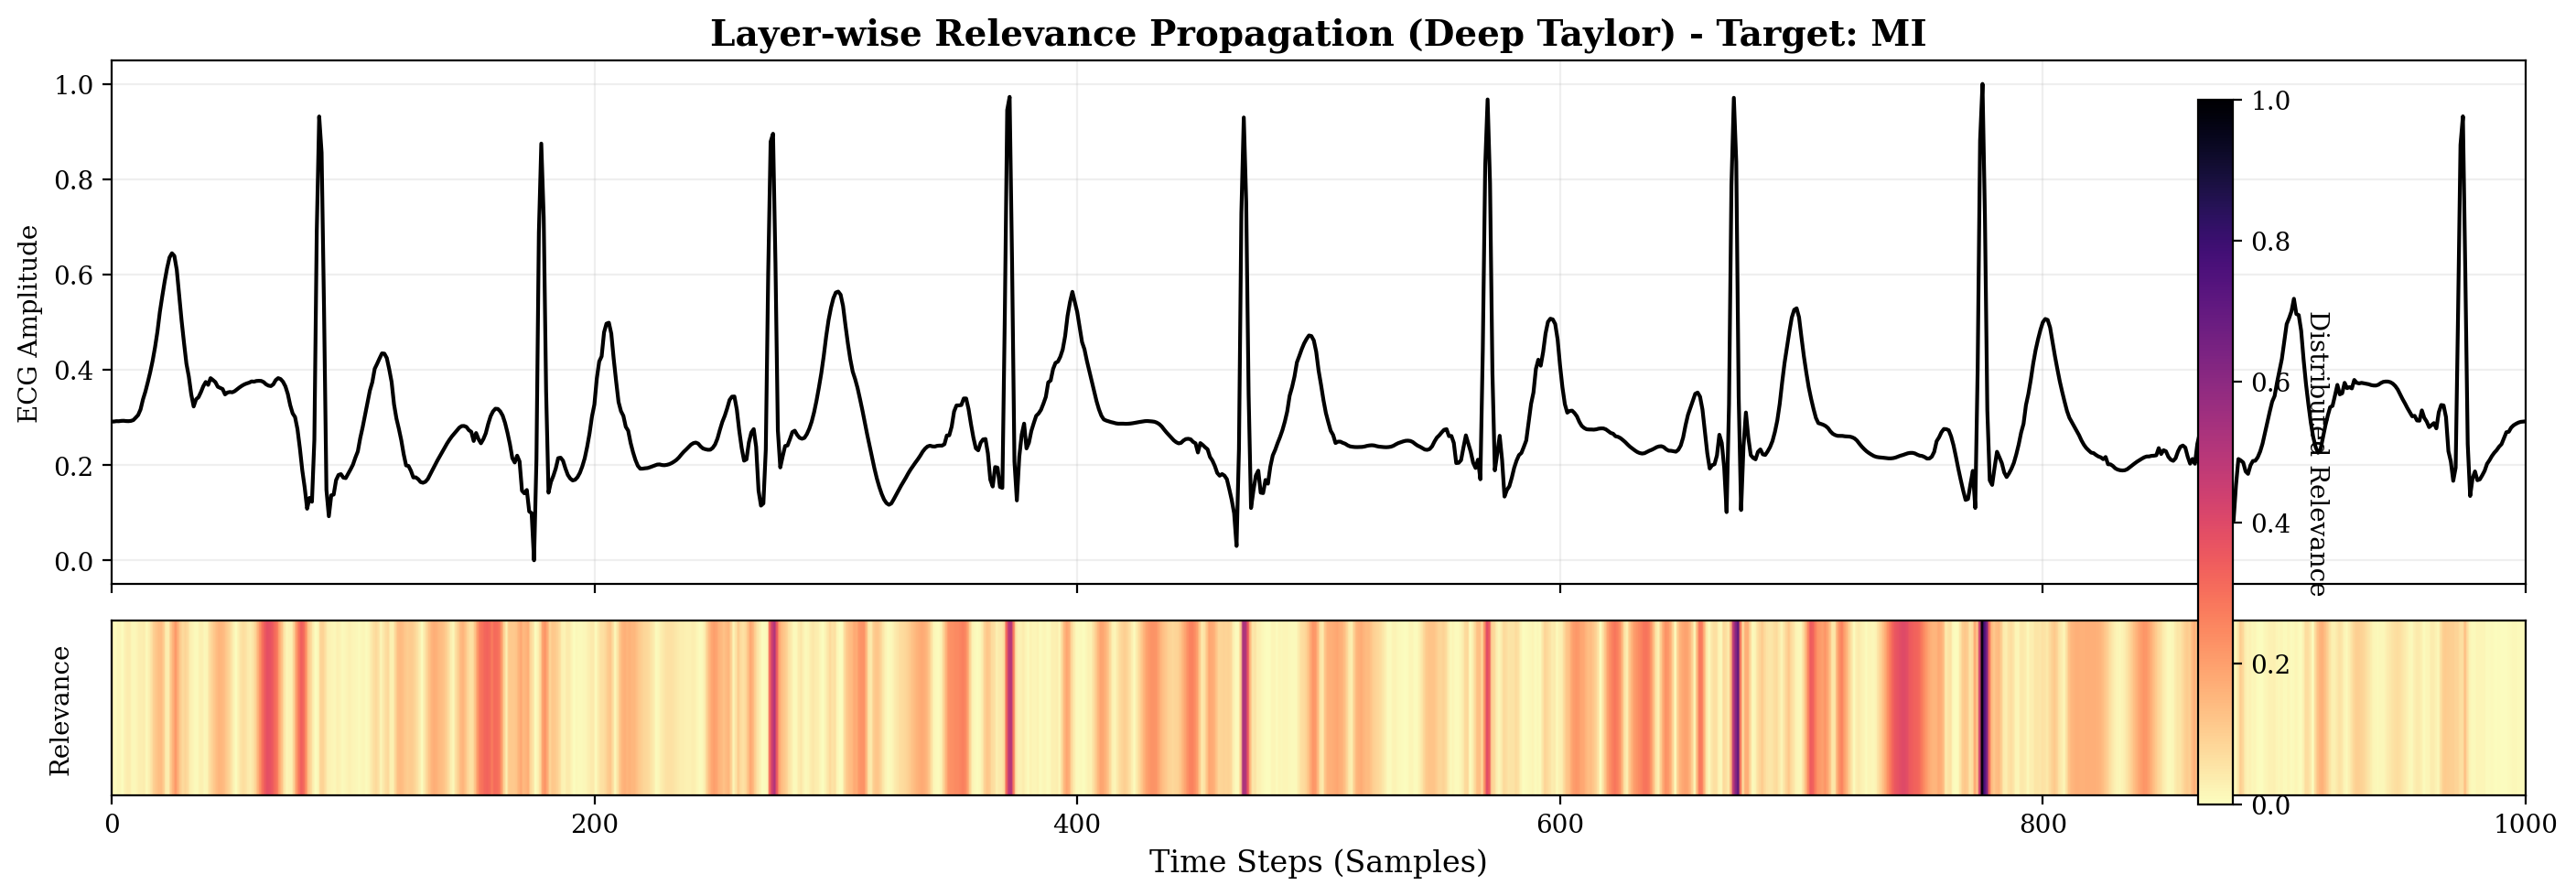

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LRP
from captum.attr._utils.lrp_rules import EpsilonRule


model.eval()
sample_batch_x, sample_batch_y = next(iter(test_loader))
sample_input = sample_batch_x[0:1].to(device)
sample_input.requires_grad = True

target_class_idx = 1
target_name = superclasses[target_class_idx]
lead_idx = 1
lead_signal = sample_input[0, lead_idx, :].detach().cpu().numpy()
time_steps = np.arange(len(lead_signal))


for name, module in model.named_modules():
    if isinstance(module, (torch.nn.Conv1d, torch.nn.Linear, torch.nn.BatchNorm1d, torch.nn.AdaptiveAvgPool1d)):
        setattr(module, 'rule', EpsilonRule())


lrp = LRP(model)
attr_lrp = lrp.attribute(sample_input, target=target_class_idx)


attr = attr_lrp[0, lead_idx, :].detach().cpu().numpy()

attr_abs = np.abs(attr)
if np.max(attr_abs) > 0:
    attr_norm = attr_abs / np.max(attr_abs)
else:
    attr_norm = attr_abs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)


ax1.plot(time_steps, lead_signal, color='black', linewidth=1.5)
ax1.set_title(f'Layer-wise Relevance Propagation (Deep Taylor) - Target: {target_name}', fontsize=14, fontweight='bold')
ax1.set_ylabel('ECG Amplitude')
ax1.grid(True, alpha=0.2)


extent = [0, len(time_steps), 0, 1]
im = ax2.imshow(attr_norm[np.newaxis, :], aspect='auto', cmap='magma_r', extent=extent)

ax2.set_yticks([])
ax2.set_xlabel('Time Steps (Samples)', fontsize=12)
ax2.set_ylabel('Relevance', labelpad=15)


cbar = fig.colorbar(im, ax=[ax1, ax2], fraction=0.05, pad=0.02)
cbar.set_label('Distributed Relevance', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 2-Deeplift

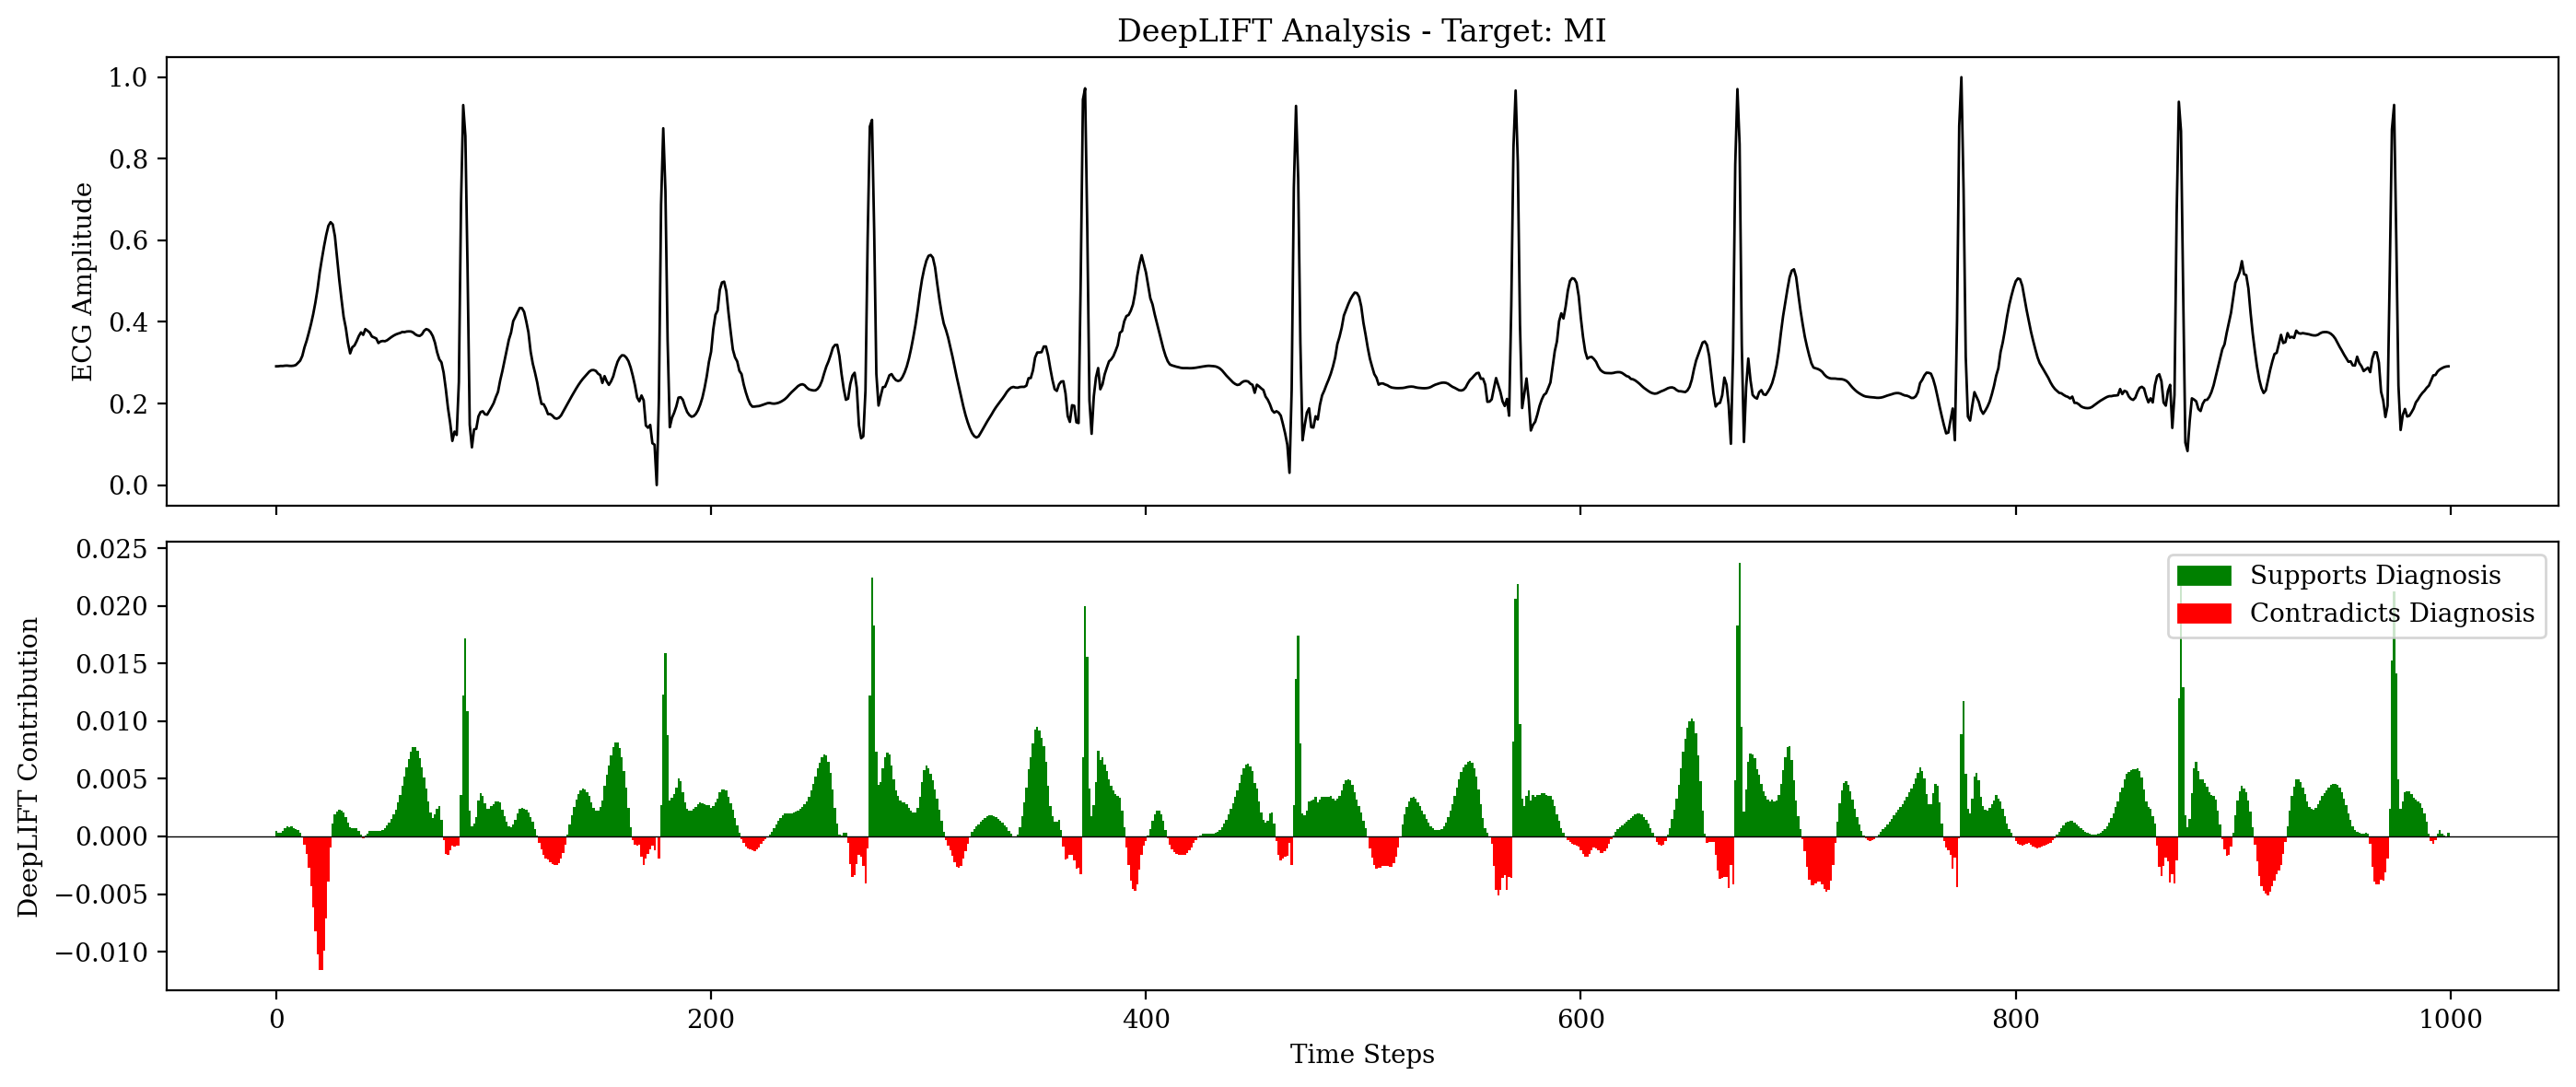

In [ ]:
dl = DeepLift(model)
baselines = torch.zeros_like(sample_input)
attr_dl = dl.attribute(sample_input, baselines=baselines, target=target_class_idx)


attr = attr_dl[0, lead_idx, :].detach().cpu().numpy()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

ax1.plot(time_steps, lead_signal, color='black', linewidth=1)
ax1.set_title(f'DeepLIFT Analysis - Target: {target_name}')
ax1.set_ylabel('ECG Amplitude')

colors = ['green' if x > 0 else 'red' for x in attr]
ax2.bar(time_steps, attr, color=colors, width=1.0)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('DeepLIFT Contribution')
ax2.set_xlabel('Time Steps')


import matplotlib.patches as mpatches
ax2.legend(handles=[mpatches.Patch(color='green', label='Supports Diagnosis'),
                    mpatches.Patch(color='red', label='Contradicts Diagnosis')], loc='upper right')

plt.tight_layout()
plt.show()

mi -> high st elevation green line supports mi

# 3-SmoothGrad

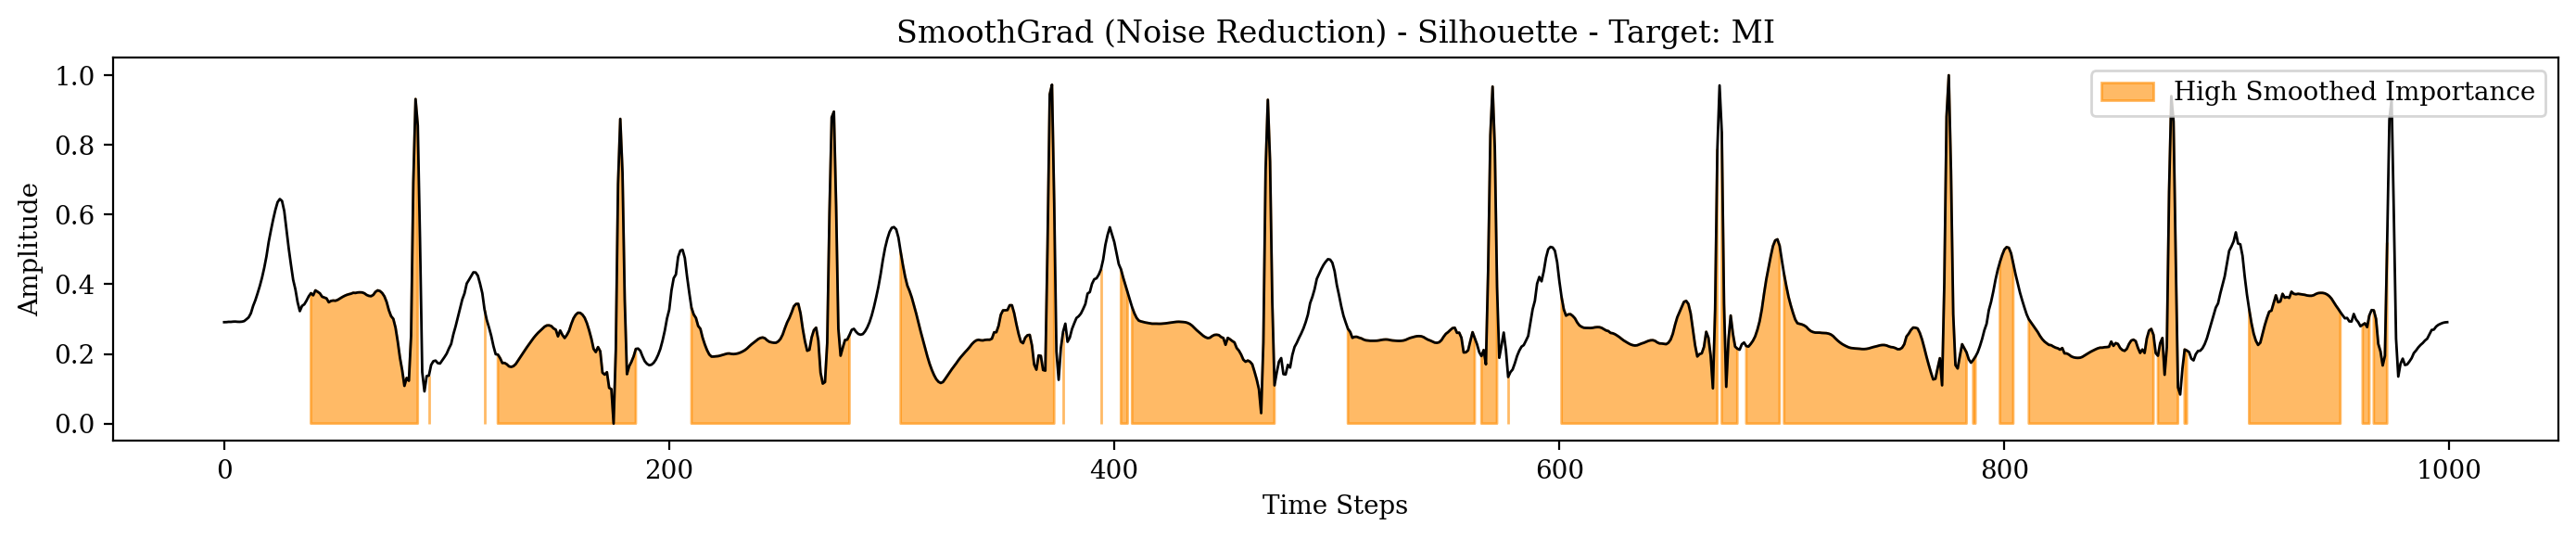

In [ ]:
nt = NoiseTunnel(Saliency(model))
attr_sg = nt.attribute(sample_input, nt_type='smoothgrad', nt_samples=20, stdevs=0.1, target=target_class_idx)

attr = attr_sg[0, lead_idx, :].detach().cpu().numpy()
attr = np.abs(attr)
attr = attr / np.max(attr) if np.max(attr) > 0 else attr

fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(time_steps, lead_signal, color='black', linewidth=1)


ax.fill_between(time_steps, lead_signal.min(), lead_signal,
                where=(attr > 0.15),
                color='darkorange', alpha=0.6, label='High Smoothed Importance')

ax.set_title(f'SmoothGrad (Noise Reduction) - Silhouette - Target: {target_name}')
ax.set_xlabel('Time Steps')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 4-Saliency

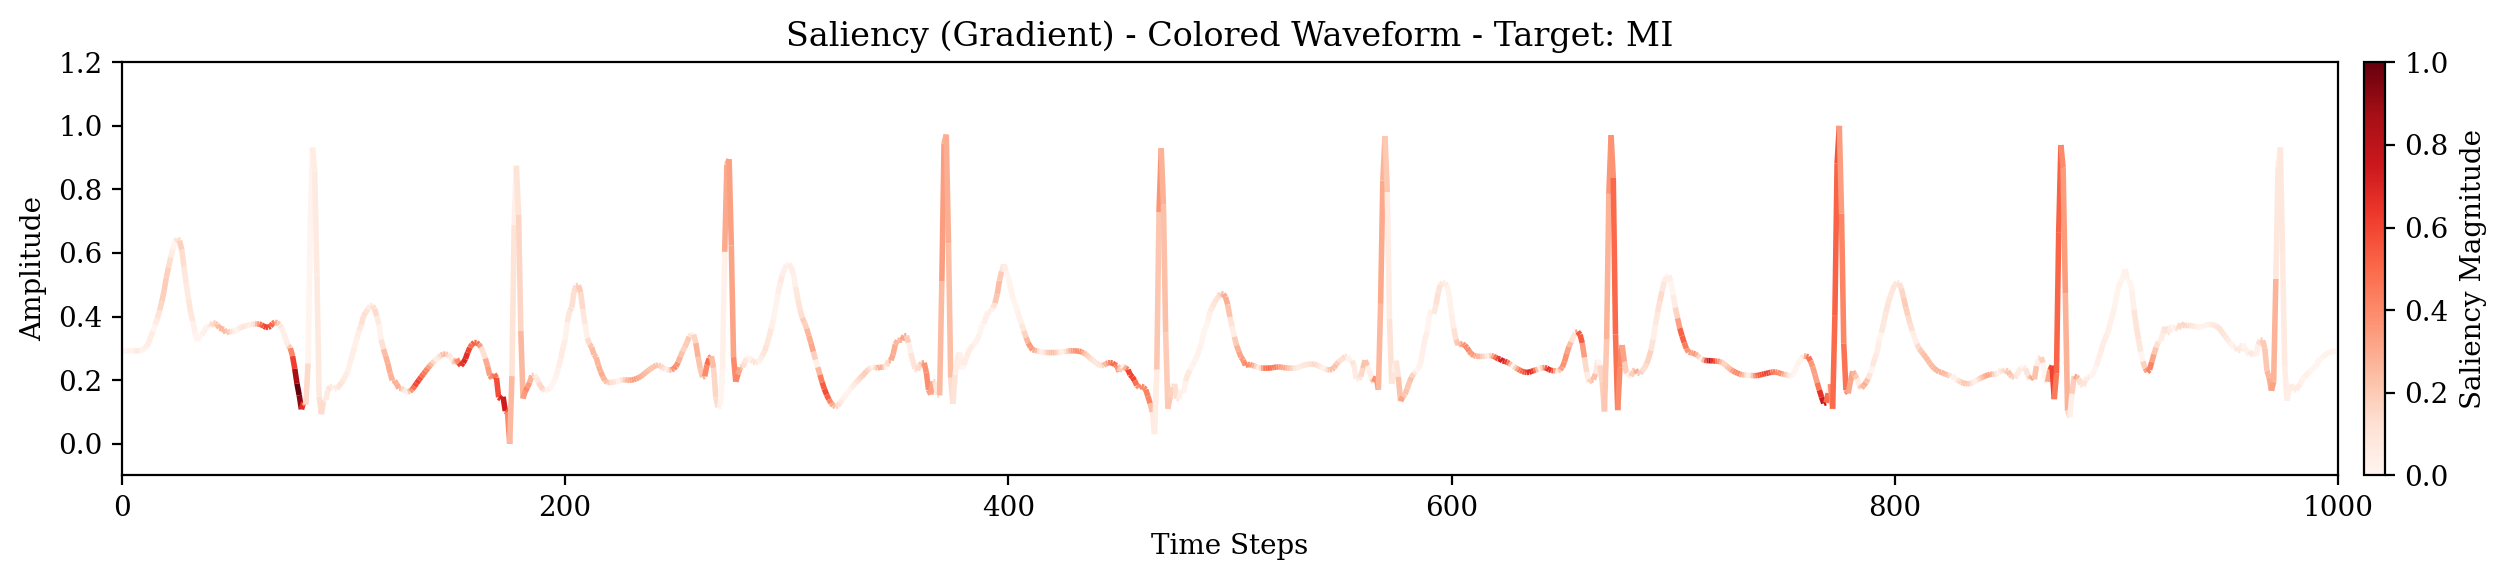

In [ ]:
sal = Saliency(model)
attr_sal = sal.attribute(sample_input, target=target_class_idx)


attr = attr_sal[0, lead_idx, :].detach().cpu().numpy()
attr = np.abs(attr)
attr = attr / np.max(attr) if np.max(attr) > 0 else attr

fig, ax = plt.subplots(figsize=(14, 3))
points = np.array([time_steps, lead_signal]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)


norm = plt.Normalize(0, 1)
lc = LineCollection(segments, cmap='Reds', norm=norm, linewidths=2)
lc.set_array(attr)
line = ax.add_collection(lc)

ax.set_xlim(0, len(time_steps))
ax.set_ylim(lead_signal.min() - 0.1, lead_signal.min() + 1.2)
fig.colorbar(line, ax=ax, label='Saliency Magnitude', pad=0.01)

plt.title(f'Saliency (Gradient) - Colored Waveform - Target: {target_name}')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Gradient Shap

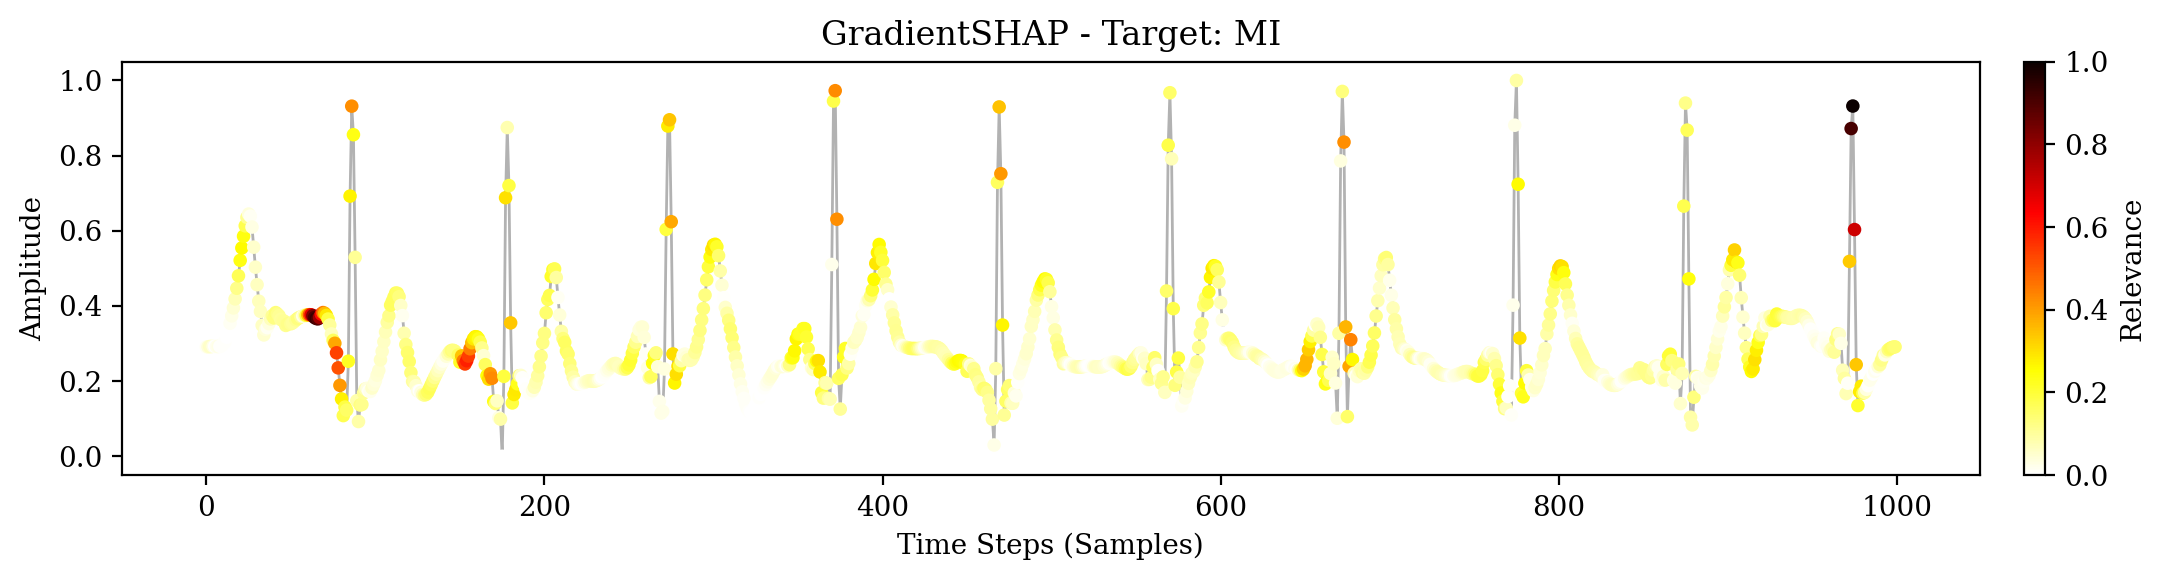

In [ ]:
gs = GradientShap(model)
baselines = torch.zeros_like(sample_input)
attr_gs = gs.attribute(sample_input, baselines=baselines, target=target_class_idx)
plot_xai(attr_gs, "GradientSHAP")

# Guided Backpropagation

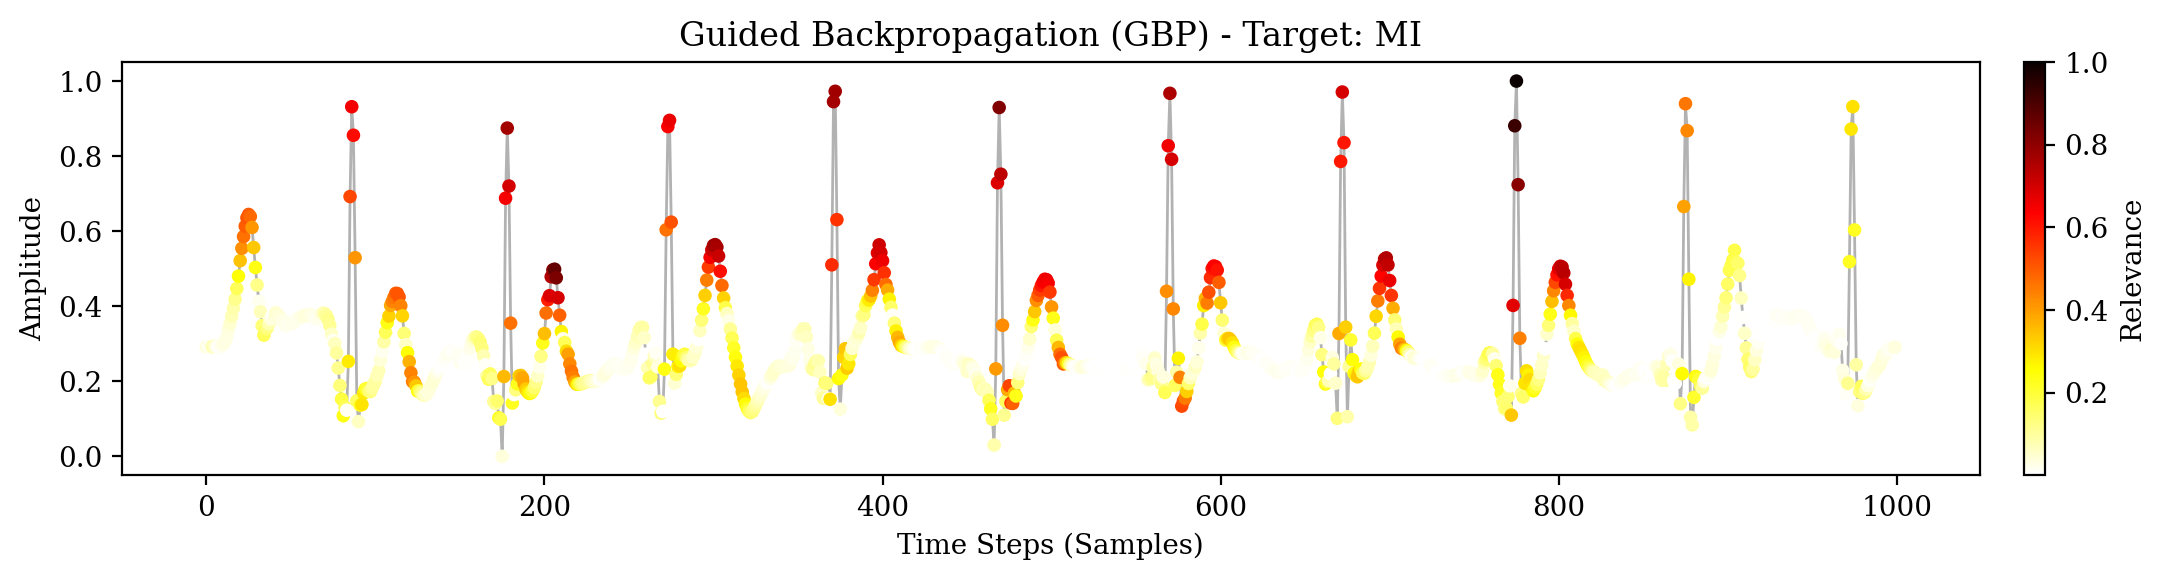

In [ ]:
gbp = GuidedBackprop(model)
attr_gbp = gbp.attribute(sample_input, target=target_class_idx)
plot_xai(attr_gbp, "Guided Backpropagation (GBP)")